In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
import math
from tqdm import tqdm
import unicodedata
from datetime import datetime
import os
import seaborn as sns

from sklearn.neighbors import BallTree

In [5]:
# tự điều chỉnh cho khớp
# DATASET_PATH = "./part1/part1/"
DATASET_PATH = "./dataset/"
START_FILE = 104
END_FILE = 189
SCALE = 0.3
FILE_NAME = "sub_raw_"

In [6]:
###Load all bus's status data from all the file contained in data folder
# Phát có chạy một số hàm (thêm thuộc tính, day, hour lấy từ realtime rồi vẽ histplot) cho các file sub_raw thì thấy
# mỗi file sẽ là của một ngày và trong khoảng 2 tiếng
# do đó tui sẽ lấy 12*7 file subraw từ 04 để có được dữ liệu từ cn đến t7 (đủ các ngày)
# nhưng vì số lượng quá lớn, nổ máy nên cấn sample lại (Phát chọn chia bin mỗi 15 phút ~ 1 file 8 bin mỗi bin chỉ lấy 10%)
# thì sau cùng tổng hợp bao nhiêu đó file + sampling ta có dataset gồm 1092330 mẫu
def get_waypoints(file_path, frac):
    with open(file_path, "r", encoding="utf-8") as f:
        data = json.load(f)
        data = [item["msgBusWayPoint"] for item in data]
        df = pd.DataFrame(data)
        
        df["bin"] = pd.cut(df["datetime"], bins = 8)

        df = (
            df.groupby("bin", group_keys=False, observed=False)
              .apply(lambda x: x.sample(frac=frac), include_groups=False)
        )
        
        return df

In [8]:
#
# Đoạn mã tổng hợp dữ liệu từ các file sub_raw
#
dfs = []
for i in tqdm(range(START_FILE, END_FILE)): # all 7 day file
    file_name = FILE_NAME+str(i)
    file_path = DATASET_PATH+file_name+".json"
    dfs.append(get_waypoints(file_path, SCALE))

# dfs là một list DataFrame
df = pd.concat(dfs, ignore_index=True)
print(len(df))
print(df.head())
print(df.tail())

df.to_json("data_raw.json", orient="records", force_ascii=False, indent=4)

100%|██████████| 85/85 [02:03<00:00,  1.45s/it]


5343384
                                             vehicle  speed    datetime  \
0  cf76b7815145d1da999cecddf796421cb39c0defb5bad4...    NaN  1742638784   
1  cf76b7815145d1da999cecddf796421cb39c0defb5bad4...    NaN  1742638906   
2  cf76b7815145d1da999cecddf796421cb39c0defb5bad4...    NaN  1742639464   
3  cf76b7815145d1da999cecddf796421cb39c0defb5bad4...    NaN  1742640109   
4  cf76b7815145d1da999cecddf796421cb39c0defb5bad4...    NaN  1742639807   

           x          y  heading ignition aircon driver door_up door_down  \
0  106.62006  10.801085      NaN      NaN    NaN    NaN     NaN       NaN   
1  106.62006  10.801085      NaN      NaN    NaN    NaN     NaN       NaN   
2  106.62006  10.801085      NaN      NaN    NaN    NaN     NaN       NaN   
3  106.62006  10.801085      NaN      NaN    NaN    NaN     NaN       NaN   
4  106.62006  10.801085      NaN      NaN    NaN    NaN     NaN       NaN   

  working  
0     NaN  
1     NaN  
2     NaN  
3     NaN  
4     NaN  
      

# LOAD BUS's STATUS DATA & STATION DATA

In [9]:
###Load station data from bus_station file
with open("bus_station.json", "r", encoding="utf-8") as f:
    station_dataset = json.load(f)

station_data = []
for route in station_dataset:
    stations = route['Stations']
    for station in stations:
        station['Lat'] = float(station['Lat'])
        station['Lng'] = float(station['Lng'])
        station_data.append(station)

station_df = pd.DataFrame(station_data)
print(station_df.head())
print(len(station_df))

             AddressNo    Code        Lat         Lng                    Name  \
0  Công trường Mê Linh   BX 06  10.776790  106.705856     Công Trường Mê Linh   
1                   21  Q1 031  10.773299  106.706359           Bến Bạch Đằng   
2                  2-4  Q1 020  10.770885  106.705549  Cục Hải Quan Thành Phố   
3                   84  Q1 021  10.770980  106.703027                  Chợ Cũ   
4                  122  Q1 022  10.771054  106.701676        Trường Cao Thắng   

                                              Routes        Search  \
0                                             01, 02  CTML CtML TS   
1      01, 02, 03, 12, 120, 19, 45, 53, 56, 61-6, 88    BBD 21 TDT   
2         01, 02, 03, 12, 123, 124, 19, 56, 61-6, 88  CHQTP 2-4 HN   
3  01, 02, 03, 12, 123, 124, 19, 45, 56, 61-6, 75...      CC 84 HN   
4  01, 02, 03, 12, 123, 124, 19, 45, 56, 61-6, 75...    TCT 122 HN   

           Status StopID  StopType         Street  
0  Đang khai thác  10033    Bến xe      

# PROCESS BUS's STATUS DATAFRAME

In [10]:
###Drop unnecessary column in bus's status data (heading, aircon, working)
df = df.drop(["heading", "aircon", "working", "ignition"], axis = 1)
df.head(5)

,vehicle,speed,datetime,x,y,driver,door_up,door_down
0,cf76b7815145d1da999cecddf796421cb39c0defb5bad4...,NaN,1742638784,106.62006,10.801085,NaN,NaN,NaN
1,cf76b7815145d1da999cecddf796421cb39c0defb5bad4...,NaN,1742638906,106.62006,10.801085,NaN,NaN,NaN
2,cf76b7815145d1da999cecddf796421cb39c0defb5bad4...,NaN,1742639464,106.62006,10.801085,NaN,NaN,NaN
3,cf76b7815145d1da999cecddf796421cb39c0defb5bad4...,NaN,1742640109,106.62006,10.801085,NaN,NaN,NaN
4,cf76b7815145d1da999cecddf796421cb39c0defb5bad4...,NaN,1742639807,106.62006,10.801085,NaN,NaN,NaN


In [11]:
###Convert time function that help to convert from unix time to real life time
def unix_to_datetime(unix_time):
    return datetime.fromtimestamp(unix_time).strftime("%d-%m-%Y %H:%M:%S")

###Apply convert time to every bus's status samples
df['realtime'] = df['datetime'].apply(unix_to_datetime)

###Sort df with vehicle and datetime features
df = df.sort_values(['vehicle', 'datetime'])

###Drop duplicate sample (drop samples which have the same value of vehicle, x, y to others)
df = df.drop_duplicates(subset=['vehicle', 'x', 'y'])

print(len(df))
print(df.head())

3362021
                                                  vehicle  speed    datetime  \
146529  00ce11f64a76aa7893b5426f873294be9c81d881676e08...    NaN  1742678396   
147351  00ce11f64a76aa7893b5426f873294be9c81d881676e08...    9.0  1742678712   
143122  00ce11f64a76aa7893b5426f873294be9c81d881676e08...    NaN  1742678772   
143650  00ce11f64a76aa7893b5426f873294be9c81d881676e08...   44.0  1742678860   
145905  00ce11f64a76aa7893b5426f873294be9c81d881676e08...   33.0  1742678910   

                 x          y driver door_up door_down             realtime  
146529  106.667263  10.805425    NaN     NaN       NaN  23-03-2025 04:19:56  
147351  106.667025  10.804813    NaN     NaN       NaN  23-03-2025 04:25:12  
143122  106.666990  10.804821    NaN     NaN       NaN  23-03-2025 04:26:12  
143650  106.665071  10.803428    NaN     NaN       NaN  23-03-2025 04:27:40  
145905  106.662736  10.801688    NaN     NaN       NaN  23-03-2025 04:28:30  


# PROCESS STATION DATAFRAME

In [12]:
###Rename Lat, Lng features of station dataframe
station_df.rename(columns={'Lat': 'y', 'Lng': 'x'}, inplace=True)
station_df.head()

,AddressNo,Code,y,x,Name,Routes,Search,Status,StopID,StopType,Street
0,Công trường Mê Linh,BX 06,10.776790,106.705856,Công Trường Mê Linh,"01, 02",CTML CtML TS,Đang khai thác,10033,Bến xe,Thi Sách
1,21,Q1 031,10.773299,106.706359,Bến Bạch Đằng,"01, 02, 03, 12, 120, 19, 45, 53, 56, 61-6, 88",BBD 21 TDT,Đang khai thác,10079,Trụ dừng,Tôn Đức Thắng
2,2-4,Q1 020,10.770885,106.705549,Cục Hải Quan Thành Phố,"01, 02, 03, 12, 123, 124, 19, 56, 61-6, 88",CHQTP 2-4 HN,Đang khai thác,10076,Nhà chờ,Hàm Nghi
3,84,Q1 021,10.770980,106.703027,Chợ Cũ,"01, 02, 03, 12, 123, 124, 19, 45, 56, 61-6, 75...",CC 84 HN,Đang khai thác,10078,Nhà chờ,Hàm Nghi
4,122,Q1 022,10.771054,106.701676,Trường Cao Thắng,"01, 02, 03, 12, 123, 124, 19, 45, 56, 61-6, 75...",TCT 122 HN,Đang khai thác,10080,Nhà chờ,Hàm Nghi


# CALCULATE THE DISTANCE

In [13]:
###Calculate function that helps to calculate the distance between 2 point with lat and lng
def distance_calc(a, b):
    R = 6371
    
    y1 = math.radians(a['y'])
    x1 = math.radians(a['x'])
    y2 = math.radians(b['y'])
    x2 = math.radians(b['x'])
    
    dlat = y2 - y1
    dlng = x2 - x1
    
    a = math.sin(dlat/2)**2 + math.cos(y1)*math.cos(y2)*math.sin(dlng/2)**2
    c = 2 * math.asin(math.sqrt(a))
    
    return R * c * 1000

In [14]:
print("Length before:", len(df))

station_coords = np.radians(
    station_df[['y','x']].values
)

status_coords = np.radians(
    df[['y','x']].values
)

tree = BallTree(station_coords, metric='haversine')

distances, indices = tree.query(status_coords, k=1)

distances_m = distances.flatten() * 6371000
nearest_station = station_df.iloc[indices.flatten()]['Name'].values

mask = distances_m < 20

df = df.loc[mask].copy()
df['current station'] = nearest_station[mask]
df['station distance'] = distances_m[mask]

print("Length after:", len(df))

Length before: 3362021
Length after: 191544


In [ ]:
# Old algorithm
###Iterate throught elements in bus_df to find the nearest station
###Add "current station" and "station distance" feature for every sample in bus_df
###Drop samples that have the shortest distance to the nearest station is more than 20m
# current_stations = []
# station_distances = []
# keep_mask = []

# print("Length of bus's status data at first: ", len(bus_df))
# for i in tqdm(range(len(bus_df))):
#     status = bus_df.iloc[i]
#     min_dis = 10000.0
#     min_station = ""
    
#     for j in range(len(station_df)):
#         station = station_df.iloc[j]
#         cur_dis = distance_calc(status, station)
#         if cur_dis < min_dis:
#             min_dis = cur_dis
#             min_station = station['Name']
#         if min_dis < 5:
#             break
#     if min_dis < 20:
#         current_stations.append(str(min_station))
#         station_distances.append(min_dis)
#         keep_mask.append(True)
#     else:
#         keep_mask.append(False)

# bus_df = bus_df[keep_mask].copy()
# bus_df['current station'] = current_stations
# bus_df['station distance'] = station_distances

# print("Length of bus's status after being filtered and labeled: ", len(bus_df))

In [15]:
df.head()

,vehicle,speed,datetime,x,y,driver,door_up,door_down,realtime,current station,station distance
175419,00ce11f64a76aa7893b5426f873294be9c81d881676e08...,27.0,1742682108,106.643650,10.780948,NaN,NaN,NaN,23-03-2025 05:21:48,Công ty Bông Bạch Tuyết,7.677521
180376,00ce11f64a76aa7893b5426f873294be9c81d881676e08...,32.0,1742682328,106.651553,10.769660,NaN,NaN,NaN,23-03-2025 05:25:28,Vòng xoay Lê Đại Hành,5.228663
201343,00ce11f64a76aa7893b5426f873294be9c81d881676e08...,15.0,1742686320,106.656361,10.763346,NaN,NaN,NaN,23-03-2025 06:32:00,Parkson,6.644467
189227,00ce11f64a76aa7893b5426f873294be9c81d881676e08...,35.0,1742686420,106.652843,10.768466,NaN,NaN,NaN,23-03-2025 06:33:40,Siêu thị Coormark,6.444972
202990,00ce11f64a76aa7893b5426f873294be9c81d881676e08...,22.0,1742686508,106.650040,10.771896,NaN,NaN,NaN,23-03-2025 06:35:08,Chợ Tân Phước,11.534355


# FILT DF BY DUPLICATE SAMPLES

In [16]:
###Drop samples that "vehicle" and "current station" features have the same values
is_new_block = (df['current station'] != df['current station'].shift(1)) | \
               (df['vehicle'] != df['vehicle'].shift(1))

df['block_id'] = is_new_block.cumsum()

idx_min_distance = df.groupby('block_id')['station distance'].idxmin()

###Reset the index after dropping
df_cleaned = df.loc[idx_min_distance].reset_index(drop=True)

df_cleaned = df_cleaned.drop(columns=['block_id'])

print(f"Data size at first: {len(df)}")
print(f"Data size after being filted duplicate station data: {len(df_cleaned)}")
df_cleaned.head()

Data size at first: 191544
Data size after being filted duplicate station data: 127594


,vehicle,speed,datetime,x,y,driver,door_up,door_down,realtime,current station,station distance
0,00ce11f64a76aa7893b5426f873294be9c81d881676e08...,27.0,1742682108,106.643650,10.780948,NaN,NaN,NaN,23-03-2025 05:21:48,Công ty Bông Bạch Tuyết,7.677521
1,00ce11f64a76aa7893b5426f873294be9c81d881676e08...,32.0,1742682328,106.651553,10.769660,NaN,NaN,NaN,23-03-2025 05:25:28,Vòng xoay Lê Đại Hành,5.228663
2,00ce11f64a76aa7893b5426f873294be9c81d881676e08...,15.0,1742686320,106.656361,10.763346,NaN,NaN,NaN,23-03-2025 06:32:00,Parkson,6.644467
3,00ce11f64a76aa7893b5426f873294be9c81d881676e08...,35.0,1742686420,106.652843,10.768466,NaN,NaN,NaN,23-03-2025 06:33:40,Siêu thị Coormark,6.444972
4,00ce11f64a76aa7893b5426f873294be9c81d881676e08...,22.0,1742686508,106.650040,10.771896,NaN,NaN,NaN,23-03-2025 06:35:08,Chợ Tân Phước,11.534355


In [17]:
###Calculate function that help to calculate the speed by divide s into v
def speed_calc(s, t):
    v = s / t * 3.6
    return v

In [43]:
###Function that returns the week day from reallife time's format
def get_weekday(rt):
    fmt = "%d-%m-%Y %H:%M:%S"
    dt = datetime.strptime(rt, fmt)
    return dt.weekday()

###Function that returns the weekend from reallife time's format
def get_weekend(rt):
    fmt = "%d-%m-%Y %H:%M:%S"
    dt = datetime.strptime(rt, fmt)
    return int(dt.weekday()>=5)

###Function that returns the hour from reallife time's format
def get_hour(rt):
    fmt = "%d-%m-%Y %H:%M:%S"
    dt = datetime.strptime(rt, fmt)
    return dt.hour

###Function that returns the minute from reallife time's format
def get_minute(rt):
    fmt = "%d-%m-%Y %H:%M:%S"
    dt = datetime.strptime(rt, fmt)
    return dt.minute

In [44]:
###Pairing sample with the same value of "value" feature consecutively than save in lst_data variable
lst_data = []
prev_status = None
for i in tqdm(range(len(df_cleaned))):
    cur_status = df_cleaned.iloc[i]
    if prev_status is not None and prev_status['vehicle'] == cur_status['vehicle']:
        distance = distance_calc(prev_status, cur_status)
        d_time = cur_status['datetime'] - prev_status['datetime']
        speed = speed_calc(distance, d_time)
        lst_data.append({
            # old record
            # "start station": prev_status['current station'],
            # "end station": cur_status['current station'],
            # "start time": prev_status['realtime'],
            # "end time": cur_status['realtime'],
            # "week day": get_weekday(prev_status['realtime']),
            # "distance (m)" : distance,
            # "duration (s)": d_time,
            # "speed (kmh)": speed 
            # new record
            "start time": prev_status['realtime'],
            "end time": cur_status['realtime'],
            "start station": prev_status['current station'],
            "end station": cur_status['current station'],
            "hour": get_hour(prev_status['realtime']),
            "minute": get_minute(prev_status['realtime']),
            "week day": get_weekday(prev_status['realtime']),
            "week end": get_weekend(prev_status['realtime']),
            "distance (m)" : distance,
            "duration (s)": d_time,
        })
    prev_status = cur_status

100%|██████████| 127594/127594 [00:24<00:00, 5168.61it/s]


In [45]:
###Convert from list type to Dataframe
main_df = pd.DataFrame(lst_data)
main_df.head()

,start time,end time,start station,end station,hour,minute,week day,week end,distance (m),duration (s)
0,23-03-2025 05:21:48,23-03-2025 05:25:28,Công ty Bông Bạch Tuyết,Vòng xoay Lê Đại Hành,5,21,6,1,1523.383736,220
1,23-03-2025 05:25:28,23-03-2025 06:32:00,Vòng xoay Lê Đại Hành,Parkson,5,25,6,1,876.796880,3992
2,23-03-2025 06:32:00,23-03-2025 06:33:40,Parkson,Siêu thị Coormark,6,32,6,1,686.882991,100
3,23-03-2025 06:33:40,23-03-2025 06:35:08,Siêu thị Coormark,Chợ Tân Phước,6,33,6,1,489.097757,88
4,23-03-2025 06:35:08,23-03-2025 06:35:58,Chợ Tân Phước,Ngã tư Lạc Long Quân,6,35,6,1,340.790582,50


In [46]:
###Boolean function to check if 2 input realtime value are in the same day
def is_same_day(rt1, rt2):
    fmt = "%d-%m-%Y %H:%M:%S"
    t1 = datetime.strptime(rt1, fmt)
    t2 = datetime.strptime(rt2, fmt)
    return t1.date() == t2.date()

In [47]:
###Apply the function above to main_df
drop_idx_lst = []
for i in tqdm(range(len(main_df))):
    sample = main_df.iloc[i]
    if not is_same_day(sample['start time'], sample['end time']):
        drop_idx_lst.append(i)

print("Dataset size before being filted by day: ", len(main_df))
main_df = main_df.drop(drop_idx_lst, errors='ignore')
main_df = main_df[main_df['distance (m)']>100]
main_df = main_df.reset_index(drop=True)
print("Dataset size after being filted (delete samples which have start time and end time is not at the same day): ", len(main_df))

100%|██████████| 127134/127134 [00:13<00:00, 9666.66it/s] 


Dataset size before being filted by day:  127134
Dataset size after being filted (delete samples which have start time and end time is not at the same day):  122537


In [48]:
main_df = main_df.drop(["start time", "end time"], axis=1)
###Save main_df in preprocessed_data.json file
main_df.to_json("preprocessed_data_modified.json", orient="records", force_ascii=False, indent=4)
# end here!!

             start station            end station  hour  minute  week day  \
0  Công ty Bông Bạch Tuyết  Vòng xoay Lê Đại Hành     5      21         6   
1    Vòng xoay Lê Đại Hành                Parkson     5      25         6   
2                  Parkson      Siêu thị Coormark     6      32         6   
3        Siêu thị Coormark          Chợ Tân Phước     6      33         6   
4            Chợ Tân Phước   Ngã tư Lạc Long Quân     6      35         6   

   week end  distance (m)  duration (s)  
0         1   1523.383736           220  
1         1    876.796880          3992  
2         1    686.882991           100  
3         1    489.097757            88  
4         1    340.790582            50  
122537


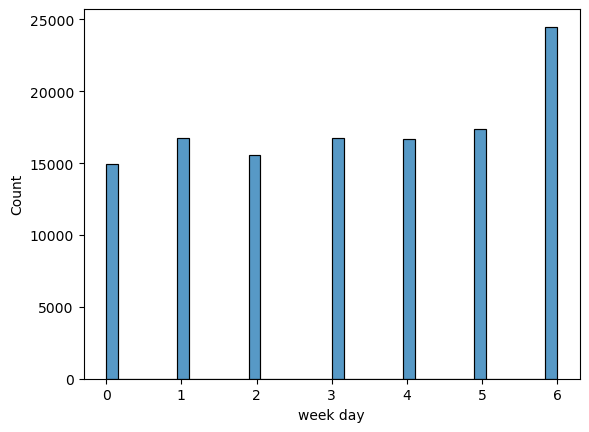

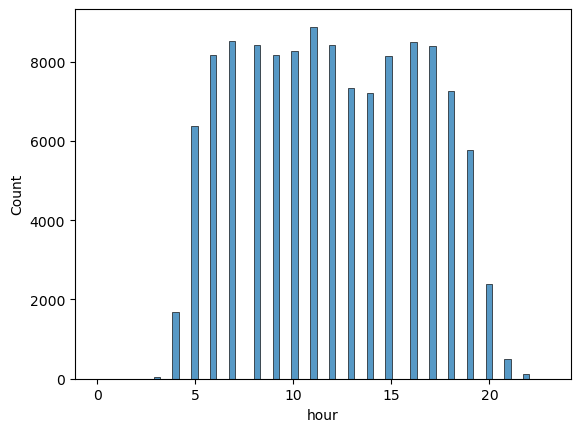

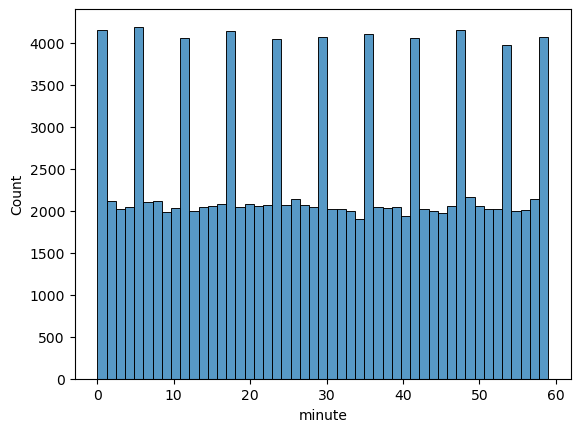

In [49]:
print(main_df.head())
print(len(main_df))

# plot
sns.histplot(data=main_df, x="week day")
plt.show()

sns.histplot(data=main_df, x="hour")
plt.show()

sns.histplot(data=main_df, x="minute")
plt.show()